In [3]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

# Transfer Learning on AutoEncoders

Test a classifier model trained from scratch vs training first an autoencoder and then transfer the weights to a classfier model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [5]:
transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

data_train = datasets.CIFAR10(root='data', train=True, download=True, transform=transformer) 
data_test = datasets.CIFAR10(root='data', train=False, download=True, transform=transformer)   

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Data categories: {data_train.classes}")
images.min(), images.max()

d:\Pablo_Data\Documentos\VSCode\deep-learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image batch shape: torch.Size([32, 3, 32, 32])
Label batch shape: torch.Size([32])
Data categories: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


(tensor(-1.), tensor(1.))

In [6]:
# create a smaller dataloader with only 2000 images for later
data_train_small = torch.utils.data.Subset(data_train, range(2000))
train_dataloader_small = DataLoader(data_train_small, batch_size=batch_size, shuffle=True)

data_test_small = torch.utils.data.Subset(data_test, range(2000))
test_dataloader_small = DataLoader(data_test_small, batch_size=batch_size, shuffle=False)

In [7]:
class CIFAR10_AE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # input size = (3, 32, 32) for CIFAR10
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = np.floor((32 - 4 + 2*1) / 2) + 1 = 16
            nn.BatchNorm2d(num_features=16), # this is used to normalize the output of the convolutional layer, which can help with training stability and convergence
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = np.floor((16 - 4 + 2*1) / 2) + 1 = 8
            nn.BatchNorm2d(num_features=32), 
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1), # output size = np.floor((8 - 4 + 2*1) / 2) + 1 = 4
            nn.BatchNorm2d(num_features=64), 
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = (4 - 1) * 2 + 4 - 2*1 = 8
            nn.BatchNorm2d(num_features=32), 
            nn.LeakyReLU(),

            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = (8 - 1) * 2 + 4 - 2*1 = 16
            nn.BatchNorm2d(num_features=16), 
            nn.LeakyReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=4, stride=2, padding=1), # output size = (16 - 1) * 2 + 4 - 2*1 = 32
            # do not add BN or activation function here because we want the output to be in the range [-1, 1] to match the normalized input pixel values
            nn.Tanh() # use Tanh activation to ensure the output pixel values are in the range [-1, 1]
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)
        
        return x
    
model = CIFAR10_AE().to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             784
       BatchNorm2d-2           [-1, 16, 16, 16]              32
         LeakyReLU-3           [-1, 16, 16, 16]               0
            Conv2d-4             [-1, 32, 8, 8]           8,224
       BatchNorm2d-5             [-1, 32, 8, 8]              64
         LeakyReLU-6             [-1, 32, 8, 8]               0
            Conv2d-7             [-1, 64, 4, 4]          32,832
       BatchNorm2d-8             [-1, 64, 4, 4]             128
         LeakyReLU-9             [-1, 64, 4, 4]               0
  ConvTranspose2d-10             [-1, 32, 8, 8]          32,800
      BatchNorm2d-11             [-1, 32, 8, 8]              64
        LeakyReLU-12             [-1, 32, 8, 8]               0
  ConvTranspose2d-13           [-1, 16, 16, 16]           8,208
      BatchNorm2d-14           [-1, 16,

In [8]:
# test one forward pass to see the print statements in action
model_ae = CIFAR10_AE().to(device)
loss_fn = nn.MSELoss() # for autoencoders, we typically use MSE loss to measure the difference between the input and the reconstructed output
images, labels = next(iter(train_dataloader))
images = images.to(device)
output = model_ae(images)
loss = loss_fn(output, images)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 3, 32, 32])
Loss: 0.3744637966156006


In [9]:
def train_one_epoch_ae(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    device: torch.device,
                    ):
    model.train()
    train_loss = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, X)  # for autoencoders, the target is the input itself

        # Update training loss
        train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss


def train_ae(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device,
          ):

    train_losses_epochs = []
    val_losses_epochs = []

    for epoch in range(epochs):
        train_loss = train_one_epoch_ae(model, train_dataloader, loss_fn, optimizer, device)

        # Calculate average training loss for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        train_losses_epochs.append(avg_train_loss)

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X, y in val_dataloader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = loss_fn(outputs, X)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        val_losses_epochs.append(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    return train_losses_epochs, val_losses_epochs

In [11]:
loss_fn = nn.MSELoss()
epochs = 10

model_ae = CIFAR10_AE().to(device)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, test_loss = train_ae(model_ae, train_dataloader, test_dataloader, loss_fn, optimizer, epochs, device)

Epoch [1/10], Train Loss: 0.0292, Val Loss: 0.0137
Epoch [2/10], Train Loss: 0.0146, Val Loss: 0.0116
Epoch [3/10], Train Loss: 0.0118, Val Loss: 0.0091
Epoch [4/10], Train Loss: 0.0100, Val Loss: 0.0087
Epoch [5/10], Train Loss: 0.0088, Val Loss: 0.0073
Epoch [6/10], Train Loss: 0.0082, Val Loss: 0.0071
Epoch [7/10], Train Loss: 0.0078, Val Loss: 0.0057
Epoch [8/10], Train Loss: 0.0074, Val Loss: 0.0054
Epoch [9/10], Train Loss: 0.0072, Val Loss: 0.0056
Epoch [10/10], Train Loss: 0.0070, Val Loss: 0.0058


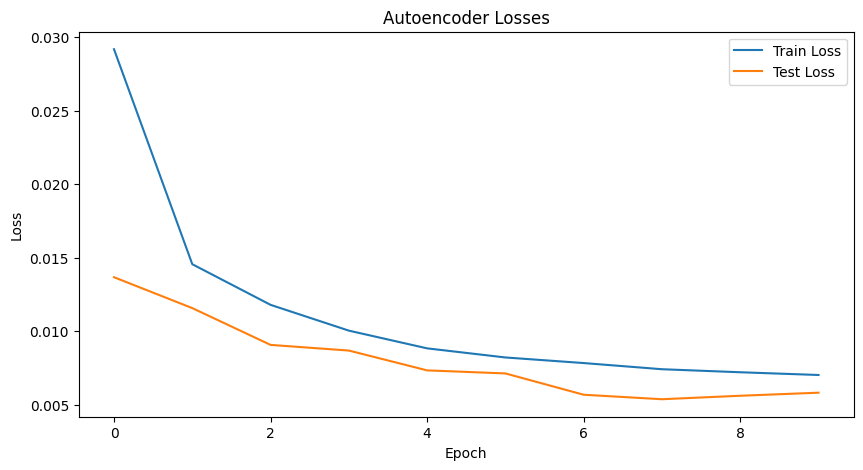

In [15]:
# plot losses
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.title('Autoencoder Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # input size = (3, 32, 32)
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = np.floor((32 - 3 + 2*1) / 2) + 1 = 16
            nn.BatchNorm2d(num_features=16), 
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = np.floor((16 - 3 + 2*1) / 2) + 1 = 8
            nn.BatchNorm2d(num_features=32), 
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1), # output size = np.floor((8 - 3 + 2*1) / 2) + 1 = 4
            nn.BatchNorm2d(num_features=64), 
            nn.LeakyReLU(),        )

        self.fnn = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=64*4*4, out_features=128),
            nn.LeakyReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.LeakyReLU(),
            nn.Linear(in_features=64, out_features=10) # 10 classes for CIFAR-10
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.fnn(x)
        
        return x
    
model = CIFAR10_CNN().to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             784
       BatchNorm2d-2           [-1, 16, 16, 16]              32
         LeakyReLU-3           [-1, 16, 16, 16]               0
            Conv2d-4             [-1, 32, 8, 8]           8,224
       BatchNorm2d-5             [-1, 32, 8, 8]              64
         LeakyReLU-6             [-1, 32, 8, 8]               0
            Conv2d-7             [-1, 64, 4, 4]          32,832
       BatchNorm2d-8             [-1, 64, 4, 4]             128
         LeakyReLU-9             [-1, 64, 4, 4]               0
          Flatten-10                 [-1, 1024]               0
           Linear-11                  [-1, 128]         131,200
        LeakyReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
        LeakyReLU-14                   

In [17]:
 # test one forward pass to see the print statements in action
model_cnn = CIFAR10_CNN().to(device)
loss_fn = nn.CrossEntropyLoss() 
images, labels = next(iter(train_dataloader))
images, labels = images.to(device), labels.to(device)
output = model_cnn(images)
loss = loss_fn(output, labels)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 10])
Loss: 2.3136088848114014


In [18]:
def train_one_epoch(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   device: torch.device): # Added device
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    
    for batch, (X, y) in enumerate(train_dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device, # Added device
          epochs: int):
    
    # Move the entire model to the device once at the start
    model.to(device)
    
    losses_epochs = [] 
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        # Pass device to the epoch function
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer, device)

        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                # Move test data to device
                X, y = X.to(device), y.to(device)
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [ ]:
# trained a new model from scratch (not pre-trained) with the smaller dataloader
loss_fn = nn.CrossEntropyLoss()
epochs = 10
model_cnn = CIFAR10_CNN().to(device)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, train_acc, test_acc = train(model_cnn, train_dataloader_small, test_dataloader_small, loss_fn, optimizer, device, epochs)

# we can appreciate the risk of having a small dataset, the training accuracy is very high but the test accuracy is very low, which indicates overfitting to the training data
# in this cases, transfer learning can be very useful to leverage the knowledge learned from a larger dataset to improve performance on a smaller dataset.

Epoch [1/10], Train Loss: 2.0321, Train Accuracy: 0.2431, Test Accuracy: 0.3333
Epoch [2/10], Train Loss: 1.6785, Train Accuracy: 0.3924, Test Accuracy: 0.3552
Epoch [3/10], Train Loss: 1.4796, Train Accuracy: 0.4559, Test Accuracy: 0.4191
Epoch [4/10], Train Loss: 1.2473, Train Accuracy: 0.5347, Test Accuracy: 0.4469
Epoch [5/10], Train Loss: 1.0189, Train Accuracy: 0.6483, Test Accuracy: 0.4187
Epoch [6/10], Train Loss: 0.8806, Train Accuracy: 0.6825, Test Accuracy: 0.4330
Epoch [7/10], Train Loss: 0.6683, Train Accuracy: 0.7743, Test Accuracy: 0.4469
Epoch [8/10], Train Loss: 0.4486, Train Accuracy: 0.8532, Test Accuracy: 0.4097
Epoch [9/10], Train Loss: 0.2837, Train Accuracy: 0.9182, Test Accuracy: 0.4350
Epoch [10/10], Train Loss: 0.1794, Train Accuracy: 0.9474, Test Accuracy: 0.4102


In [40]:
model_cnn_transfer = CIFAR10_CNN().to(device) # create a new instance of the CNN model for transfer learning
model_cnn_transfer

CIFAR10_CNN(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
  (fnn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [41]:
model_ae

CIFAR10_AE(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(16, e

In [51]:
# transfer the weights from the encoder of the autoencoder to the encoder of the CNN
model_cnn_transfer = CIFAR10_CNN().to(device) # create a new instance of the CNN model for transfer learning
model_cnn_transfer.encoder.load_state_dict(model_ae.encoder.state_dict())

# in case we want to freeze the encoder weights so they are not updated during training, we can set requires_grad to False for all the parameters in the encoder
# for param in model_cnn_transfer.encoder.parameters():
#     param.requires_grad = False

<All keys matched successfully>

In [ ]:
loss_fn = nn.CrossEntropyLoss()
epochs = 10
optimizer = torch.optim.Adam(model_cnn_transfer.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, train_acc, test_acc = train(model_cnn_transfer, train_dataloader_small, test_dataloader_small, loss_fn, optimizer, device, epochs)

# there is not a significant improvement in performance, which could be due to several reasons:
# The autoencoder was trained on the same dataset (CIFAR-10), so the features learned by the encoder may not be very different from what the CNN would learn on its own. 

Epoch [1/10], Train Loss: 2.0471, Train Accuracy: 0.2361, Test Accuracy: 0.3497
Epoch [2/10], Train Loss: 1.6487, Train Accuracy: 0.3934, Test Accuracy: 0.3998
Epoch [3/10], Train Loss: 1.4124, Train Accuracy: 0.4866, Test Accuracy: 0.4191
Epoch [4/10], Train Loss: 1.2532, Train Accuracy: 0.5337, Test Accuracy: 0.4306
Epoch [5/10], Train Loss: 1.0357, Train Accuracy: 0.6260, Test Accuracy: 0.4221
Epoch [6/10], Train Loss: 0.7992, Train Accuracy: 0.7282, Test Accuracy: 0.3948
Epoch [7/10], Train Loss: 0.6306, Train Accuracy: 0.7812, Test Accuracy: 0.4211
Epoch [8/10], Train Loss: 0.4587, Train Accuracy: 0.8586, Test Accuracy: 0.4330
Epoch [9/10], Train Loss: 0.3214, Train Accuracy: 0.9033, Test Accuracy: 0.4330
Epoch [10/10], Train Loss: 0.2072, Train Accuracy: 0.9484, Test Accuracy: 0.4162
